This jupyter notebook gives an overview of SNR/exposure time calculations and gives example use cases of how 'ExposureTimeSNRCalculatorESC.py' can be used to make such calculations.

To follow along please make a copy of the entire wcc exposure time calculator repository:

`git clone https://github.com/uasal/stp_etc_esc/`

Also you will need to install STSci's synphot package
Info here: https://synphot.readthedocs.io/en/latest/

# SNR Basics

### SNR for a given Exposure Time

Signal-to-Noise Ratio
$$
SNR = \frac{S_{source}}{N_{total}}
$$
where $S_{source}$ is the source signal and $N_{total}$ is the total signal noise.

For independent noise sources, the total noise is the sum of the individual noise variances $N_{total}^2 = \sigma_{total}^2 = \sum_i^n \sigma_i^2$.

Noise can come from:
1. Target Source: $S_{source} = \sigma_{source}^2$
2. Zodi Background: $S_{zodi} = \sigma_{zodi}^2$
3. Exozodi: $S_{exozodi} = \sigma_{exozodi}^2$
4. Thermally Excited Electrons (Dark Current): $S_{dark \; current} = \sigma_{dark \; current}^2$
5. Readout Noise: $R^2 = \sigma_{readout}^2$
6. Speckle Noise $S_{*} = \sigma_{*}^2$

So
$$
N_{total} = \sqrt{ \sigma_{source}^2 + \sigma_{zodi}^2 + \sigma_{exozodi}^2 + \sigma_{dark \; current}^2 + \sigma_{readout}^2 + \sigma_{*}^2}
$$

Thus
$$
SNR = \frac{\sigma_{source}^2}{\sqrt{ \sigma_{source}^2 + \sigma_{zodi}^2 + \sigma_{exozodi}^2 + \sigma_{dark \; current}^2 + \sigma_{readout}^2 + \sigma_{*}^2}}
$$

However, this implies that if we integrate forever, we can always reach the SNR we want to achieve. Fundamentally, we are limited by an intrinsic noise floor. In the context of high contrast imaging, this noise floor can be represented as
$$
M = S_{*}f_p
$$
where $f_p$ is a post-processing gain factor. In the calculation, $f_p$ is the reciprocal of the expected ability to subtract residual starlight speckles. I.e., a factor of 10 in post-processing gain corresponds to the intrinsic noise floor of the observation being a factor of 10 below the residual starlight speckle noise. This term is added to SNR in quadrature, so now

$$
SNR = \frac{\sigma_{source}^2}{\sqrt{ \sigma_{source}^2 + \sigma_{zodi}^2 + \sigma_{exozodi}^2 + \sigma_{dark \; current}^2 + \sigma_{readout}^2 + \sigma_{*}^2+(Mt_{int})^2}}
$$

When observations are made, each of the following are recorded by the CCD in the corresponding units (usually):
1. Target Source: $S_{source}$ in [$photon \; s^{-1}$] or [$ADU \; s^{-1}$]
2. Zodi Background: $S_{zodi}$ in [$photon \; s^{-1} \; pixel^{-1}$] or [$ADU \; s^{-1} \; pixel^{-1}$]
3. Exozodi Background: $S_{exozodi}$ in [$photon \; s^{-1} \; pixel^{-1}$] or [$ADU \; s^{-1} \; pixel^{-1}$]
4. Thermally Excited Electrons (Dark Current): $S_{dark \; current}$ [$e^{-} \; s^{-1} \; pixel^{-1}$]
5. Readout Noise: $R^2$ [$e^{-} \; pixel^{-1}$]
6. Speckle Noise $S_{*} = \sigma_{*}^2$ in [$photon \; s^{-1}$] or [$ADU \; s^{-1}$]

If $S_{source}$, $S_{zodi}$, $S_{exozodi}$, and $S_{*}$ are in ADU units, then we can convert to $e^{-}$ units using the CCD's gain and multiplying by exposure time t and number of pixels $n_p$ when needed. The resulting SNR equation is a follows:
$$
SNR = \frac{ S_{source} G t_{int} }{ \sqrt{ S_{source} G t_{int} + S_{zodi} G t_{int} n_p + S_{exozodi} G t_{int} n_p + S_{dark \; current} t_{int} n_p + R^2 n_p \frac{t_{int}}{t_{exp}} + S_{*} G t_{int} + (M G t_{int})^2 } }
$$

### Total Integration Time for a given SNR

From the above equation for SNR, we can solve for a total integration time as a function of SNR and individual exposure time and get the following quadratic equation:
$$
t_{int} = \frac{S_{source}+S_{zodi}+S_{exozodi}+S_{*}+S_{DC} n_p+R^2 n_p t_{exp}^{-1}}{\frac{S_{source}}{SNR}^2 - M^2}
$$



# How to Use Exposure Time Calculator

### Creating Synthetic Astrophysical Observations

In order to accurately recreate observed results, we need to recreate the conditions that are typical of such observations.

When considering all electromagnetic effects that go into an observation we need to first consider the background environment of the source. The background will have an associated spectra (the zodiacal and exozodiacal light backgrounds are relevant in this case.)

After the background spectra is considered, we can then consider the source spectra (in this case, a substellar companion). We can approximate a source spectra to differing levels of complexity as required. From simplest to more complex, we can create flat spectra, blackbody approximations, or import simulated/observed spectra from spectral libraries available online (TO BE IMPLEMENTED). All these spectra can then be manipulated to simulate different planet orbital separations, sizes, etc.

Once we have our observational parameters set up, we need only consider effects from hardware.

To do this, we can "build" an observatory, including information such as it primary mirror diameter, mirror material, number of mirrors, the focal length, and we can add on a detector and include its properties (gain, dark current, etc.) as well.

We can do all this utilizing the Synphot package developed by STSci (https://synphot.readthedocs.io/en/latest/)

### About ExposureTimeSNRCalculatorESC.py

The ExposureTimeSNRCalculatorESC.py file provides a straightforward framework for making SNR-related calculations using Synphot.

### Using ExposureTimeSNRCalculatorESC.py

In [1]:
import config_stp
import config_stp_esc
from stp_etc_esc import ExposureTimeSNRCalculatorESC as etsc  # import the package
from astropy import units as u
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

Now we can start by constructing our observatory. We do this by first calling `etsc.Observatory()` and providing a name, the primary mirror aperture, and the focal length that we want the observatory to have. This creates an instantiation of an observatory object that we can further mold to our liking.

NOTE: We can then save this observatory object and get information from it using `[Observatory].get_info()`.

In [2]:
ESC = etsc.Observatory(telescope_name="Extrasolar Camera"
                      , telescope_diameter=6.5*u.m
                       , telescope_focal_len=97.5*u.m)
ESC.get_info()

***__name=Extrasolar Camera 

***__diameter_primary=6.5 m 

***__surf_area=33.18307240354219 m2 

***__lyot_stop_area=0 

***__num_mirrors=0 

***__focal_len=97.5 m 

***__f_num=15.0 

***__psf_diameter=None 

***__plate_scale=None 

***__gain=None 

***__dark_current=None 

***__read_noise=None 

***__num_pixels=None 

***__num_psf_pixels=None 

***__pixel_size=None 

***__sensor_area=None 

***__sensor_temp=None 

***__rawDH_contrast=None 

***__primary_filter=None 

***__sky_counts=0 

***__well_depth=None 

***__bandpass=SpectralElement
Model: Box1D
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
    amplitude  x_0    width 
    --------- ------ -------
          1.0 9000.0 10000.0 

***__precoron_bandpass=SpectralElement
Model: Box1D
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
    amplitude  x_0    width 
    --------- ------ -------
          1.0 9000.0 10000.0 

***__coron_bandpass=SpectralElement
Model: Box1D
Inputs: ('x',)
Outputs: ('y',)
Model se

In [3]:
# we can also use
#ESC.as_array()  # to get this info as a numpy array

In [4]:
# or
#ESC.as_df()  # as a pandas dataframe object

In [5]:
# All observatories have the following attribute
#ESC.attribute

Now that we have our observatory object instantiated, we can continue to add further details about it's hardware setup.

We can either add components one by one or call on a special function to add a preconfigured observatory with STP components.

`[observatory].make_STP(subap)` includes the following components:

- Which ESC subaperture you choose (subap='A' or subap='B' for 2.43 and 1.3m subapertures respectively)
- Mirrors:
    - With coatings as specified in config_stp and config_stp_esc
- A ZWO IMX455 CMOS Chip: 
    - With configurable noise/gain settings (defaults: gain=100 dB, temp=0 °C)
- A color filter:
    - Specified when the function is called
- Generic, flat transmission/reflective optics (quarter wave plates)
- Transmissive optics (polarizers, with transmission specificed in config_stp_esc')
- Separation in angle units, which maps to a throughput curve as a function of lambda/D for the coronagraph focal plane mask
- The fraction of the primary diameter that represents the diameter of the lyot stop
- A fractional filter bandwidth fbw for a flat 98% transmission filter
- An expected rawDH_contrast to calculate speckle noise
- A post-processing gain factor (ppFac), needed for SNR calculations
    
This function also sets the psf settings, so only a source/background need to be added to make an observation and perform SNR/exposure time calculations.

By default, the backend of the exposure time calculator will populate all hardware specifications as defined in common_params.toml in config_stp_esc. However, you can input your own dictionaries for configuration files and support data paths, as long as they follow a consistent format with configuration files described in config_stp and config_stp_esc. PLEASE NOTE that as the code is constructed, you cannot specify the source separation unless you change the appropriate keyword in common_params.toml in config_stp_esc. The separation cannot be manually input outside of that, as the throughput/QE curve is generated assuming a throughput for the coronagraph focal plane mask (which varies as a function of separation).

In [6]:
#stp_config = #Your telescope config dictionary here
#esc_config = #Your ESC config dictionary here
#stp_support_path = Your telescope config support data path here
#esc_support_path = Your ESC config support data path here

#Note that the keywords telconfig, escconfig, telpath, and escpath by default load from config_stp and config_stp_esc.
#Contrast must be 'spec' or 'CBE'

preconfig_ESC = ESC.make_STP(subap='A',plot=False,telconfig='UM',escconfig='UM',telpath='UM',escpath='UM',contrast='CBE')

/Users/jrhom/anaconda3/envs/esc_etc_Dec2025_srr/lib/python3.11/site-packages/utils_config/config_loader.py:103: UserWarning: Environment variable '$UASAL_ARCHIVE' referenced by 'optics -> m1 -> opd_map' is not set so '$UASAL_ARCHIVE/projects/um/mirror_data/opd_maps/M1_map.fits' will not expand. If using 'optics -> m1 -> opd_map' please set '$UASAL_ARCHIVE' and call this method again.  Reference the README for instructions on setting up an environment variable.
  return {k: self._expand_env_vars(v, path + [k]) for k, v in config.items()}
/Users/jrhom/anaconda3/envs/esc_etc_Dec2025_srr/lib/python3.11/site-packages/utils_config/config_loader.py:103: UserWarning: Environment variable '$UASAL_ARCHIVE' referenced by 'optics -> m1 -> opd_map_goal' is not set so '$UASAL_ARCHIVE/projects/um/mirror_data/opd_maps/M1_goal_map.fits' will not expand. If using 'optics -> m1 -> opd_map_goal' please set '$UASAL_ARCHIVE' and call this method again.  Reference the README for instructions on setting up an

Before we add a source and/or background to make an observation, let's check the composite bandpass (throughput) profile of our observatory. We can also check the core throughput (focal plane mask throughput) and the noncoronagraphic throughput (everything else).

In [7]:
#ESC.diameter_primary = 3.0*u.m
ESC.get_info()

***__name=Extrasolar Camera 

***__diameter_primary=3.0 m 

***__surf_area=5.6106344849942165 m2 

***__lyot_stop_area=5.6106344849942165 m2 

***__num_mirrors=14 

***__focal_len=110.12638863915413 m 

***__f_num=36.70879621305138 

***__psf_diameter=56.65350859871641 um 

***__plate_scale=0.008671917437783469 

***__gain=0.9239970596457494 electron / ct 

***__dark_current=0.005246290870658241 electron / (pix s) 

***__read_noise=1.832077426554004 electron(1/2) / pix(1/2) 

***__num_pixels=43220.88331801706 pix 

***__num_psf_pixels=169.0 pix 

***__pixel_size=4.63 um / pix 

***__sensor_area=926521.7535999999 um2 

***__sensor_temp=-12.5 deg_C 

***__rawDH_contrast=9.7e-09 

***__primary_filter=6299.999999999999 Angstrom 

***__sky_counts=0 

***__well_depth=15260.992347242305 electron / pix 

***__bandpass=SpectralElement
Model: CompoundModel
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Expression: [0] * [1] * [2] * [3] * [4] * [5] * [6] * [7] * [8] * [9] * [10] * [11] * [12] *

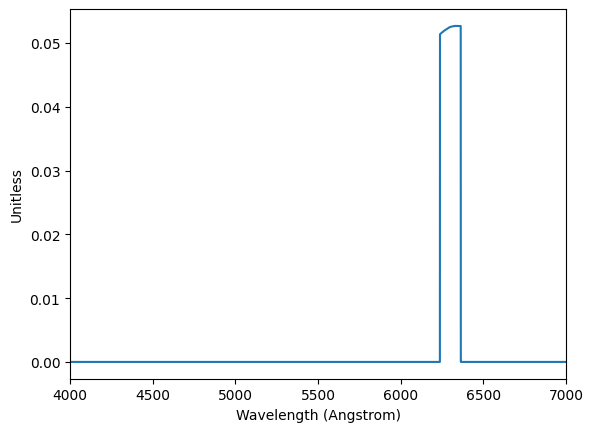

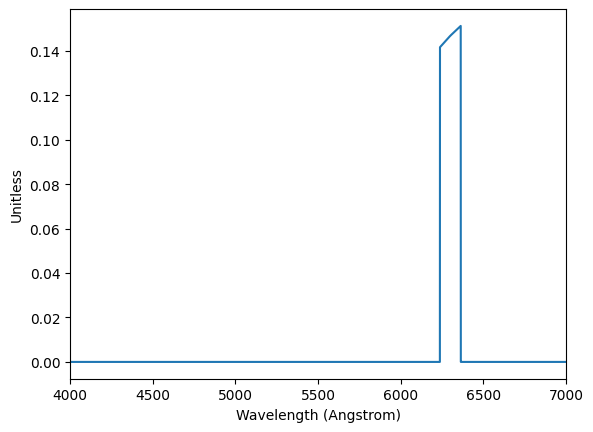

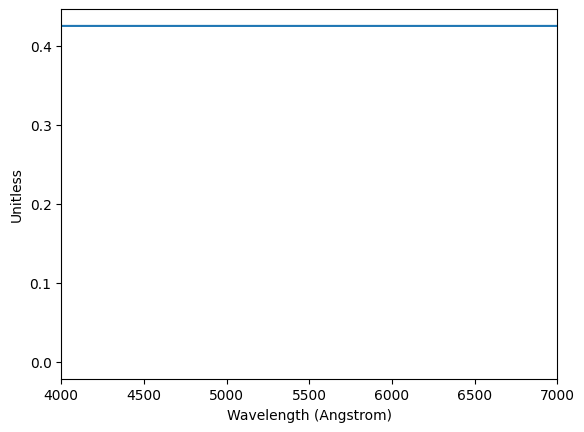

In [8]:
ESC.bandpass.plot(left=4000, right=7000)
ESC.precoron_bandpass.plot(left=4000,right=7000)
ESC.coron_bandpass.plot(left=4000,right=7000)

Synphot has a plethora of tools to take advantage of certain properties of our observatory's bandpass, such as:

In [9]:
# Finding the peak throughput of the bandpasses
print(ESC.bandpass.tpeak())
print(ESC.precoron_bandpass.tpeak())
print(ESC.coron_bandpass.tpeak())

0.05267220612456514
0.1512205341253319
0.42495524148334046


In [10]:
#ESC.bandpass = ESC.bandpass/2.5
#print(ESC.bandpass.tpeak())
#Save the noncoronagraphic throughput to a SYNPHOT bandpass fits file
#ESC.save_nonCoronThruput(savedir='/Users/jrhom/spacecoron_design_docs/Analysis/Science/etc_noncoron_throughput')

(See synphot's documentation for a more in-depth overview of inherited functions we can call on our observatory and it's properties.)

Next we must use `[observatory].calc_PSF()` to establish the PSF size for the photometry that goes into the SNR calculations

In [11]:
psf_diameter, psf_min_num_pixels = ESC.calc_PSF()
print(psf_diameter.to('um'), '\n', psf_min_num_pixels)

56.65350859871641 um 
 169.0 pix


Now we can specify a source to look at, including it's properties (TO BE ADDED: implementing planetary and stellar spectra, right now it's flat). For easy defaults, let's load in the default parameters from the configuration files in config_stp and config_stp_esc.

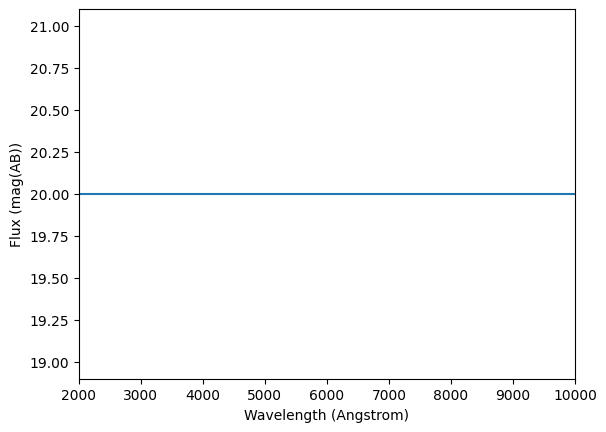

In [12]:
ESC.set_generic_source(1e-8,0,plot=True)

We can also add a background model:

(NOTE: the background noise is zero by default if [observatory].set_background() is not called)

/Users/jrhom/anaconda3/envs/esc_etc_Dec2025_srr/lib/python3.11/site-packages/config_um/support_data/astrophysics/zodiacal_model_001.fits 

 SourceSpectrum at z=0.0
Model: Empirical1D
N_inputs: 1
N_outputs: 1
Parameters: 
  points: (array([  700.,   850.,  1000., ..., 24960., 24980., 25000.],
      shape=(4173,), dtype='>f8'),)
  lookup_table: [1.67137563e-18 2.02952755e-18 2.38767947e-18 ... 1.24186365e-07
 1.24139320e-07 1.24361335e-07]
  method: linear
  fill_value: nan
  bounds_error: False 




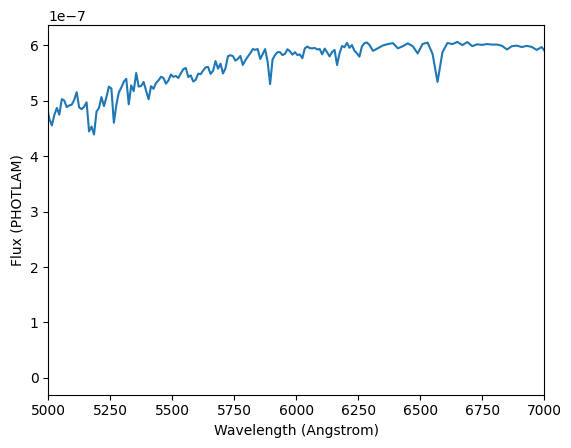

In [13]:
#zodi_model = stp_support_path / Path(stp_config['astrophysics']['zodi']['profile'])
ESC.set_background(background_file = None, plot=True) #None background file gives default background file from internal config
print(ESC.background_name, '\n'*2, ESC.background_spectrum, '\n'*2)

Now that we have our observatory built and a source to look at, we can simulate an observation. This requires setting a host star flux (in magnitudes), a planet delta magnitude (relative to the host star, in magnitudes), a background flux from zodiacal light (in magnitudes), a background flux from exozodiacal light (in magnitudes), and the flux unit system to normalize all of the fluxes in. NOTE: This takes a long time to calculate. A future feature request would involve pre-computing certain observation bandpass convolutions and load them in if available.

Once again, we can make use of the configuration parameter defaults in common_params, or specify your own.

In [14]:
#hoststarflux = esc_config['common_params']['sources']['host']['magnitude']
#planetdeltamag = esc_config['common_params']['sources']['companion']['delta_magnitude']
#bg_flux = stp_config['astrophysics']['zodi']['zodi_mag_r']
#exobg_flux = esc_config['common_params']['sources']['exozodi']['delta_magnitude']

#ESC.make_observation(hoststarflux=hoststarflux, planetdeltamag=planetdeltamag,bg_flux=bg_flux,
#                     flux_units='vega', plot=False,exobg_flux=exobg_flux)
ESC.make_observation(hoststarflux=-0.353, planetdeltamag=0,bg_flux=22.5,
                     flux_units='vega', plot=False,exobg_flux=21)

(<Quantity 3.83051235e+08 electron / s>,
 <Quantity 0.0006089 electron / s>,
 <Quantity 3.71559698 electron / s>)

### NOTE:
For unsupported systems, we will get the following error:

In [15]:
#ESC.make_observation(flux=0, flux_units='ST', plot=True)  # gives exception for unimplemented units

We can see how our observatory properties have changed:

In [16]:
ESC.get_info()

***__name=Extrasolar Camera 

***__diameter_primary=3.0 m 

***__surf_area=5.6106344849942165 m2 

***__lyot_stop_area=5.6106344849942165 m2 

***__num_mirrors=14 

***__focal_len=110.12638863915413 m 

***__f_num=36.70879621305138 

***__psf_diameter=56.65350859871641 um 

***__plate_scale=0.008671917437783469 

***__gain=0.9239970596457494 electron / ct 

***__dark_current=0.005246290870658241 electron / (pix s) 

***__read_noise=1.832077426554004 electron(1/2) / pix(1/2) 

***__num_pixels=43220.88331801706 pix 

***__num_psf_pixels=169.0 pix 

***__pixel_size=4.63 um / pix 

***__sensor_area=926521.7535999999 um2 

***__sensor_temp=-12.5 deg_C 

***__rawDH_contrast=9.7e-09 

***__primary_filter=6299.999999999999 Angstrom 

***__sky_counts=0.0006088964865256102 electron / s 

***__well_depth=15260.992347242305 electron / pix 

***__bandpass=SpectralElement
Model: CompoundModel
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Expression: [0] * [1] * [2] * [3] * [4] * [5] * [6] * [7] *

We can check the detector's saturation time using `[observatory].calc_saturation_time()`

In [17]:
ESC.dark_current = ESC.dark_current/2.5

In [17]:
ESC.calc_saturation_time()

<Quantity 0.00673306 s>

We can calculate the SNR and levels of noise sources for given exposure and integration times (in seconds) using `[observatory].calc_SNR(int_time,exp_time)`

In [22]:
ESC.calc_SNR(3600*u.s,1*u.s)

Source Counts 2.767303976512413 electron / s
DC 0.35464926285649706 electron / s
RN 2042099.2827871107 electron
Zodi 0.0006088964865256102 electron / s
Exozodi 0.0016234376150109618 electron / s
Speckles 2.684284857217038 electron / s
M 0.2684284857217038 electron / s


np.float64(5.754776758260933)

We can also calculate the time required for a given SNR and exposure time using `[observatory].calc_exp_time(req_SNR,exp_time)`. Noise terms are automatically calculated and printed for you.

In [20]:
int_time,noiseterms = ESC.calc_int_time(5,1*u.s)
print('Total Integration Time Needed',int_time)

DC 0.35464926285649706 electron / s
RN 567.2498007741974 electron / s
Zodi 0.0006088964865256102 electron / s
Exozodi 0.0016234376150109618 electron / s
Speckles 2.684284857217038 electron / s
M 0.2684284857217038 electron / (ct s)
Total Integration Time Needed 2446.1967055655914 ct s / electron


In [21]:
int_time = int_time*u.electron/u.ct
print(int_time.to(u.min))

40.769945092759855 min


Let's try to quantify what integration times are needed for a given set of exposure times and desired SNR. It's also useful to calculate dominant noise sources and how they vary across these different combinations

In [20]:
mpl.rc('font',family='Times')
plt.rcParams['xtick.labelsize']=15
plt.rcParams['ytick.labelsize']=15
int_time5SNR = np.array([])
int_time10SNR = np.array([])
DC = np.array([]) #Empty arrays for storing noise values
RN = np.array([])
Zodi = np.array([])
Exozodi = np.array([])
Speckles = np.array([])
frametimes = np.array([1.,5.,10.,30.,60.]) # in seconds, individual exposure times
for i in np.array([1.,5.,10.,30.,60.]):

	int_time,noiseterms5 = ESC.calc_int_time(5,i*u.s) #SNR, individual frame time
	int_time10,noiseterms10 = ESC.calc_int_time(10,i*u.s) #SNR, individual frame time
	int_time5SNR = np.append(int_time5SNR,int_time.value)
	int_time10SNR = np.append(int_time10SNR,int_time10.value)
	DC = np.append(DC,noiseterms5[0]*(i))
	RN = np.append(RN,noiseterms5[1]) #Note that read noise in one frame is always the same, but your total read noise depends on how often you read out the detector
	Zodi = np.append(Zodi,noiseterms5[2]*(i))
	Exozodi = np.append(Exozodi,noiseterms5[3]*(i))
	Speckles = np.append(Speckles,noiseterms5[4]*(i))

DC 0.6908257687496837 electron / s
RN 521.3078880987772 electron / s
Zodi 0.00017476055031238826 electron / s
Exozodi 0.0006349893748225627 electron / s
Speckles 0.7034467279326466 electron / s
M 0.07034467279326466 electron / (ct s)
DC 0.6908257687496837 electron / s
RN 521.3078880987772 electron / s
Zodi 0.00017476055031238826 electron / s
Exozodi 0.0006349893748225627 electron / s
Speckles 0.7034467279326466 electron / s
M 0.07034467279326466 electron / (ct s)
DC 0.6908257687496837 electron / s
RN 104.26157761975544 electron / s
Zodi 0.00017476055031238826 electron / s
Exozodi 0.0006349893748225627 electron / s
Speckles 0.7034467279326466 electron / s
M 0.07034467279326466 electron / (ct s)
DC 0.6908257687496837 electron / s
RN 104.26157761975544 electron / s
Zodi 0.00017476055031238826 electron / s
Exozodi 0.0006349893748225627 electron / s
Speckles 0.7034467279326466 electron / s
M 0.07034467279326466 electron / (ct s)
DC 0.6908257687496837 electron / s
RN 52.13078880987772 electr

/Users/jrhom/anaconda3/envs/esc_etc_Oct2024/lib/python3.11/site-packages/astropy/units/quantity.py:658: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Let's plot integration time needed to reach SNR of 5 and 10 as a function of individual exposure time. Notice how in this scenario, a 10 sigma detection is impossible.

[nan nan nan nan nan]


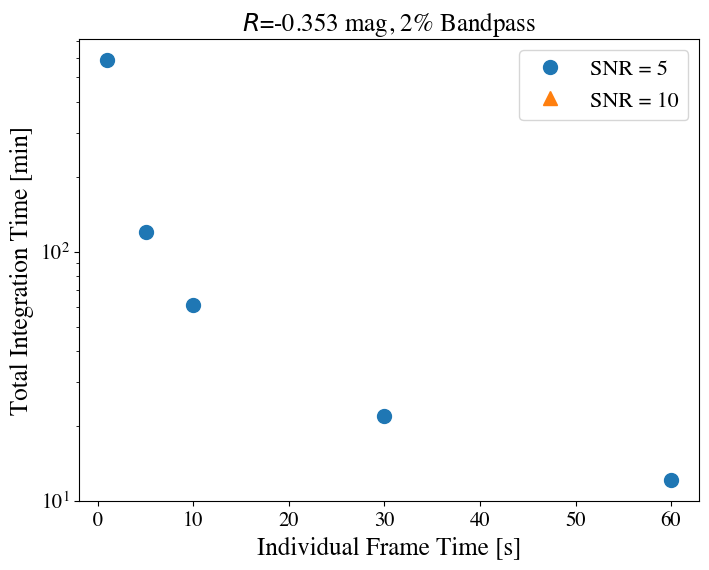

In [21]:
fig,ax = plt.subplots(1,1,figsize=(8,6))
ax.plot(frametimes,int_time5SNR/60,label='SNR = 5',linestyle='None',marker='o',markersize=10)
ax.plot(frametimes,int_time10SNR/60,label='SNR = 10',linestyle='None',marker='^',markersize=10)
ax.set_xlabel('Individual Frame Time [s]',fontsize=18)
ax.set_ylabel('Total Integration Time [min]',fontsize=18)
ax.set_yscale('log')
ax.legend(loc='best',fontsize=16)
ax.set_title(r'$R$=-0.353 mag, 2% Bandpass',fontsize=18)
fig.savefig('/Users/jrhom/m3_time2SNR.jpg')
print(int_time10SNR)

Now let's check out our noise sources when considering SNR = 5. This plot will show that for each exposure time that leads to an SNR = 5 detection, there will be this much noise per individual frame.

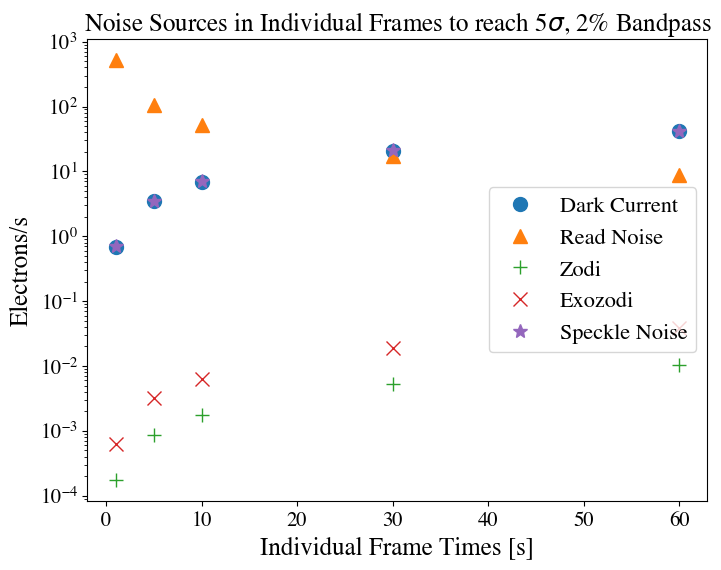

In [22]:
fig2,ax2 = plt.subplots(1,1,figsize=(8,6))
ax2.plot(frametimes,DC,label='Dark Current',linestyle='None',marker='o',markersize=10)
ax2.plot(frametimes,RN,label='Read Noise',linestyle='None',marker='^',markersize=10)
ax2.plot(frametimes,Zodi,label='Zodi',linestyle='None',marker='+',markersize=10)
ax2.plot(frametimes,Exozodi,label='Exozodi',linestyle='None',marker='x',markersize=10)
ax2.plot(frametimes,Speckles,label='Speckle Noise',linestyle='None',marker='*',markersize=10)
ax2.set_xlabel('Individual Frame Times [s]',fontsize=18)
ax2.set_ylabel('Electrons/s',fontsize=18)
ax2.set_yscale('log')
ax2.legend(loc='best',fontsize=16)
ax2.set_title(r'Noise Sources in Individual Frames to reach 5$\sigma$, 2% Bandpass',fontsize=18)
fig2.savefig('/Users/jrhom/m32percNoise.jpg')